In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [31]:
datos =pd.read_csv('/content/datos_tratados.csv')

In [32]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [33]:
datos = datos.drop(columns=['CustomerID'])

In [34]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [35]:
datos = pd.get_dummies(datos, drop_first=True)

In [36]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 7043 non-null   int64  
 1   ChargesDaily                           7043 non-null   float64
 2   ChargesMonthly                         7043 non-null   float64
 3   ChargesTotal                           7043 non-null   float64
 4   Churn_Yes                              7043 non-null   bool   
 5   Gender_Male                            7043 non-null   bool   
 6   SeniorCitizen_Yes                      7043 non-null   bool   
 7   Partner_Yes                            7043 non-null   bool   
 8   Dependents_Yes                         7043 non-null   bool   
 9   PhoneService_Yes                       7043 non-null   bool   
 10  MultipleLines_Yes                      7043 non-null   bool   
 11  Inte

In [37]:
datos = datos.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)

In [38]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 7043 non-null   int64  
 1   ChargesDaily                           7043 non-null   float64
 2   ChargesMonthly                         7043 non-null   float64
 3   ChargesTotal                           7043 non-null   float64
 4   Churn_Yes                              7043 non-null   int64  
 5   Gender_Male                            7043 non-null   int64  
 6   SeniorCitizen_Yes                      7043 non-null   int64  
 7   Partner_Yes                            7043 non-null   int64  
 8   Dependents_Yes                         7043 non-null   int64  
 9   PhoneService_Yes                       7043 non-null   int64  
 10  MultipleLines_Yes                      7043 non-null   int64  
 11  Inte

In [39]:
datos['Churn_Yes'].value_counts()

,count
Churn_Yes,
0,5174
1,1869


In [40]:
datos['Churn_Yes'].value_counts(normalize=True) * 100

,proportion
Churn_Yes,
0,73.463013
1,26.536987


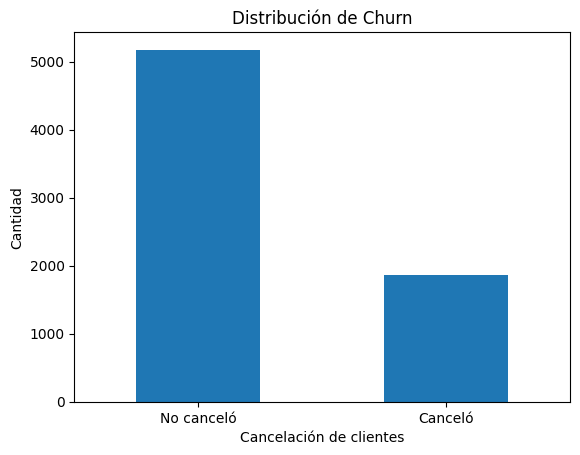

In [41]:


datos['Churn_Yes'].value_counts().plot(kind='bar')

plt.title('Distribución de Churn')
plt.xlabel('Cancelación de clientes')
plt.ylabel('Cantidad')
plt.xticks([0,1], ['No canceló', 'Canceló'], rotation=0)

plt.show()

####Se evaluó la necesidad de normalizar los datos. Este preprocesamiento es importante para modelos basados en distancia como KNN, SVM o Regresión Logística. Sin embargo, los modelos basados en árboles (Decision Tree, Random Forest o XGBoost) no son sensibles a la escala de los datos, por lo que en este análisis no se consideró necesario aplicar normalización en esta etapa.

In [42]:
corr = datos.corr()

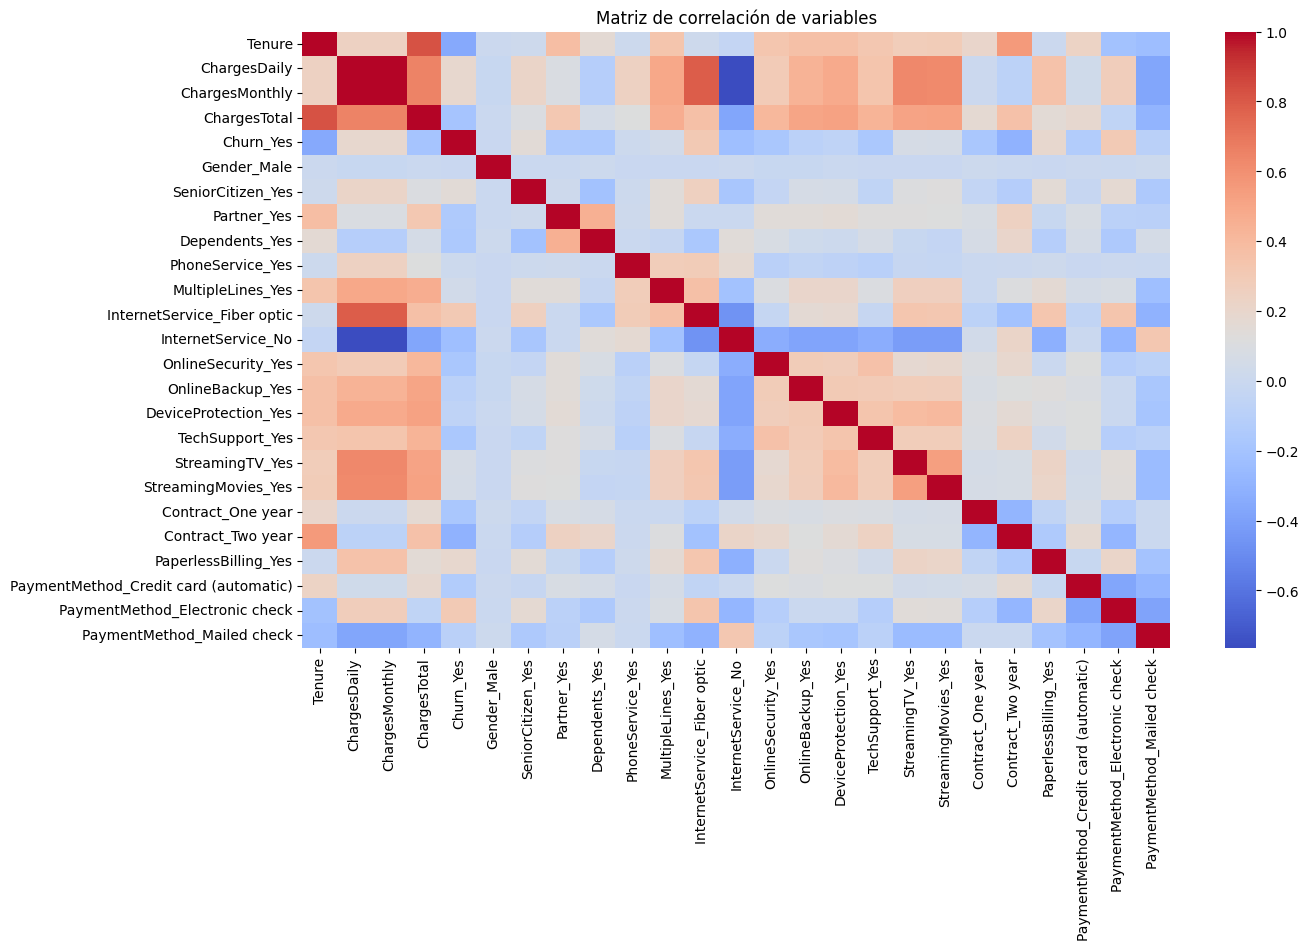

In [43]:


plt.figure(figsize=(14,8))
sns.heatmap(corr, annot=False, cmap='coolwarm')

plt.title('Matriz de correlación de variables')
plt.show()

##Tiempo de Contraro X Cancelación

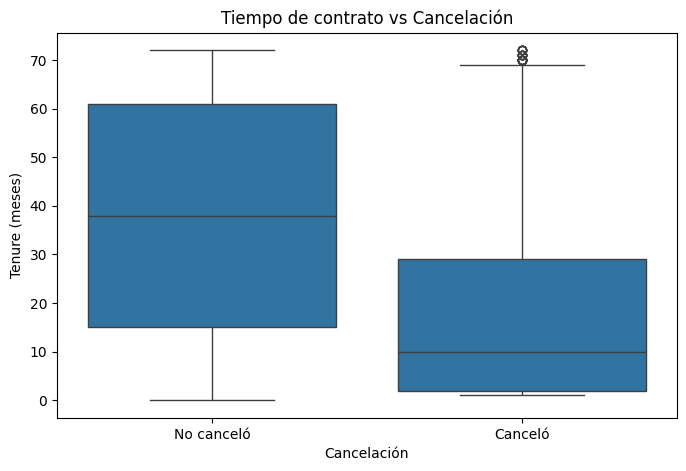

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn_Yes', y='Tenure', data=datos)

plt.title('Tiempo de contrato vs Cancelación')
plt.xlabel('Cancelación')
plt.ylabel('Tenure (meses)')
plt.xticks([0,1], ['No canceló','Canceló'])

plt.show()

##Gasto total X Cancelación

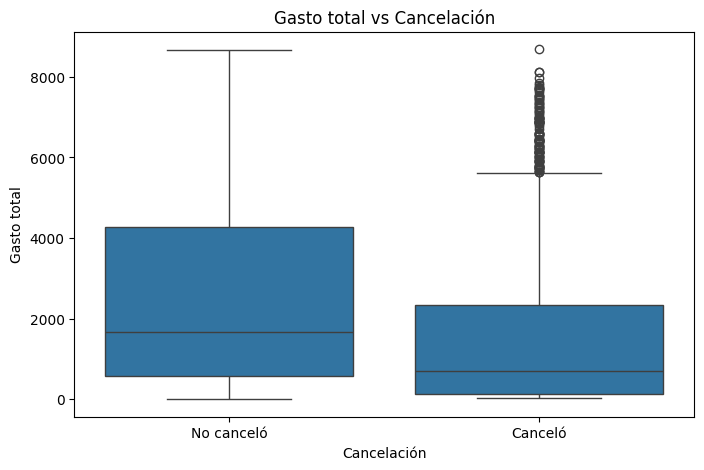

In [45]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn_Yes', y='ChargesTotal', data=datos)

plt.title('Gasto total vs Cancelación')
plt.xlabel('Cancelación')
plt.ylabel('Gasto total')

plt.xticks([0,1], ['No canceló','Canceló'])

plt.show()

##Gasto Mensual X Cancelación

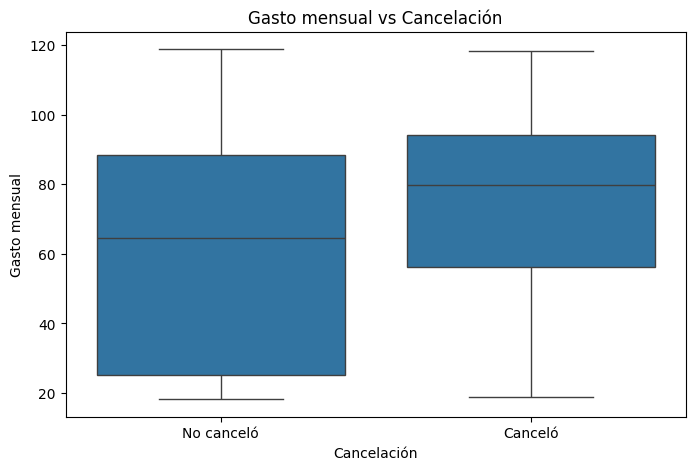

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn_Yes', y='ChargesMonthly', data=datos)

plt.title('Gasto mensual vs Cancelación')
plt.xlabel('Cancelación')
plt.ylabel('Gasto mensual')

plt.xticks([0,1], ['No canceló','Canceló'])

plt.show()

#Modelado Predictivo

In [47]:
X = datos.drop('Churn_Yes', axis=1)
y = datos['Churn_Yes']

In [48]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [49]:
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (4930, 24)
Prueba: (2113, 24)


##Regresión Logistica

In [50]:


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:


modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train_scaled, y_train)

y_pred_lr = modelo_lr.predict(X_test_scaled)

In [52]:


print("Accuracy Regresión Logística:", accuracy_score(y_test, y_pred_lr))

Accuracy Regresión Logística: 0.8154283009938476


##Arbol de decisión

In [53]:


modelo_tree = DecisionTreeClassifier(random_state=42)

modelo_tree.fit(X_train, y_train)

y_pred_tree = modelo_tree.predict(X_test)

In [54]:
print("Accuracy Árbol de Decisión:", accuracy_score(y_test, y_pred_tree))

Accuracy Árbol de Decisión: 0.7269285376242309


In [55]:
print("Regresión Logística:", accuracy_score(y_test, y_pred_lr))
print("Árbol de Decisión:", accuracy_score(y_test, y_pred_tree))

Regresión Logística: 0.8154283009938476
Árbol de Decisión: 0.7269285376242309


###Evaluando Regresión Logística

In [56]:
print("Regresión Logística")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_lr))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_lr))

Regresión Logística
Accuracy: 0.8154283009938476
Precision: 0.6731182795698925
Recall: 0.5680580762250453
F1-score: 0.6161417322834646

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1562
           1       0.67      0.57      0.62       551

    accuracy                           0.82      2113
   macro avg       0.76      0.74      0.75      2113
weighted avg       0.81      0.82      0.81      2113


Matriz de confusión:
[[1410  152]
 [ 238  313]]


###Evaluar Árbol de Decisión

In [57]:
print("Árbol de Decisión")

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1-score:", f1_score(y_test, y_pred_tree))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_tree))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_tree))

Árbol de Decisión
Accuracy: 0.7269285376242309
Precision: 0.4774305555555556
Recall: 0.49909255898366606
F1-score: 0.4880212954747116

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1562
           1       0.48      0.50      0.49       551

    accuracy                           0.73      2113
   macro avg       0.65      0.65      0.65      2113
weighted avg       0.73      0.73      0.73      2113


Matriz de confusión:
[[1261  301]
 [ 276  275]]


###Evaluar Arbol de Decisión

In [58]:
print("Árbol de Decisión")

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1-score:", f1_score(y_test, y_pred_tree))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_tree))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_tree))

Árbol de Decisión
Accuracy: 0.7269285376242309
Precision: 0.4774305555555556
Recall: 0.49909255898366606
F1-score: 0.4880212954747116

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1562
           1       0.48      0.50      0.49       551

    accuracy                           0.73      2113
   macro avg       0.65      0.65      0.65      2113
weighted avg       0.73      0.73      0.73      2113


Matriz de confusión:
[[1261  301]
 [ 276  275]]


###Matriz de Confusión Regresión Logistica

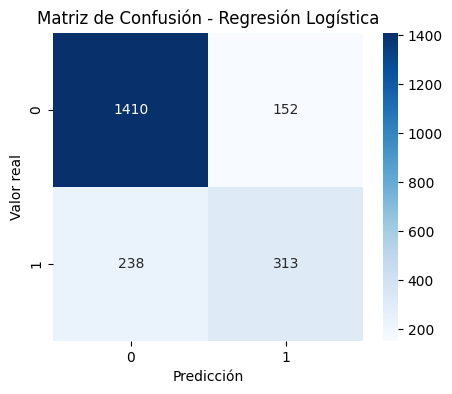

In [60]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

###Matriz de Confusión Arbol de decisiones

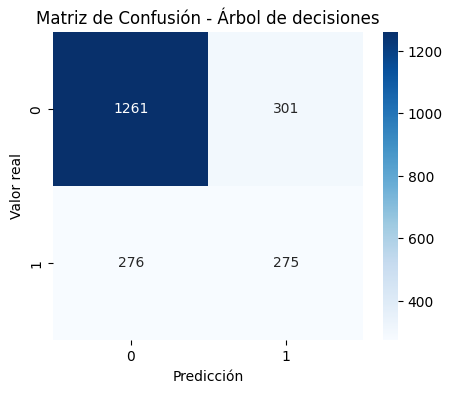

In [62]:
cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Matriz de Confusión - Árbol de decisiones")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

####Comparación de modelos

Se evaluaron dos modelos para predecir la cancelación de clientes: Regresión Logística y Árbol de Decisión. Ambos fueron evaluados utilizando métricas como exactitud (accuracy), precisión, recall y F1-score.

Desempeño

En general, la Regresión Logística mostró un desempeño más equilibrado, con mejores valores en precisión y F1-score, lo que indica una mejor capacidad para identificar correctamente a los clientes que cancelan el servicio.

Overfitting o Underfitting

El Árbol de Decisión puede presentar tendencia al overfitting, ya que este tipo de modelo puede ajustarse demasiado a los datos de entrenamiento, capturando incluso ruido en los datos. Esto puede reducir su capacidad de generalización en nuevos datos.

Por otro lado, la Regresión Logística tiende a generalizar mejor, ya que es un modelo más simple y menos propenso a sobreajustarse.

##Conclusiones

###Regresion logística

In [63]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_lr.coef_[0]
})

coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)

print(coeficientes)

                                 Variable  Coeficiente
3                            ChargesTotal     0.793651
10            InternetService_Fiber optic     0.463843
22         PaymentMethod_Electronic check     0.174844
9                       MultipleLines_Yes     0.169087
16                        StreamingTV_Yes     0.155268
20                   PaperlessBilling_Yes     0.151663
17                    StreamingMovies_Yes     0.115307
5                       SeniorCitizen_Yes     0.061828
14                   DeviceProtection_Yes     0.015357
6                             Partner_Yes     0.005963
23             PaymentMethod_Mailed check     0.005871
4                             Gender_Male    -0.024059
21  PaymentMethod_Credit card (automatic)    -0.028254
7                          Dependents_Yes    -0.049206
13                       OnlineBackup_Yes    -0.079302
1                            ChargesDaily    -0.105589
12                     OnlineSecurity_Yes    -0.121143
15        

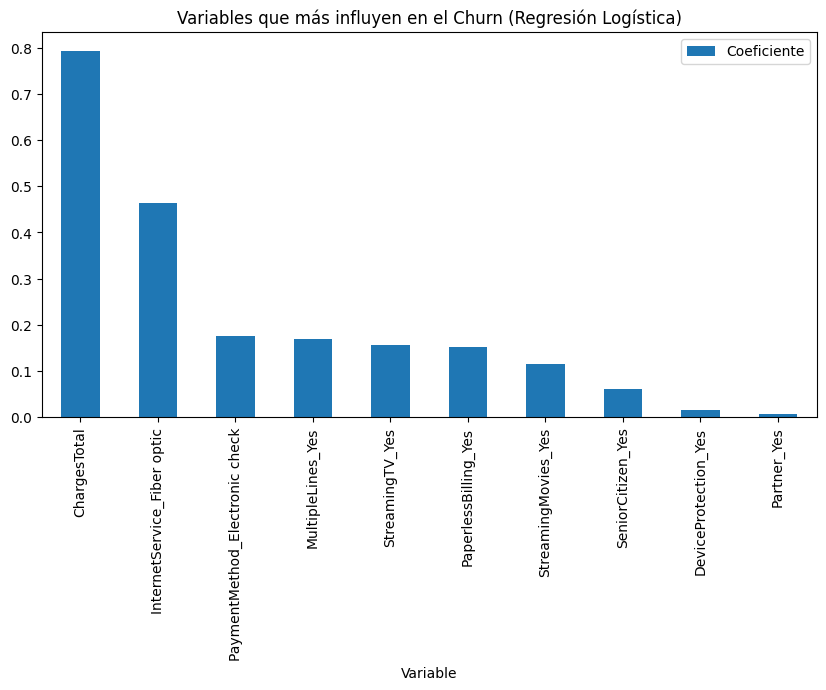

In [64]:
coeficientes.head(10).plot(
    x="Variable",
    y="Coeficiente",
    kind="bar",
    figsize=(10,5)
)

plt.title("Variables que más influyen en el Churn (Regresión Logística)")
plt.show()

###Árbol de decisiones

In [65]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_tree.feature_importances_
})

importancias = importancias.sort_values(by="Importancia", ascending=False)

print(importancias)

                                 Variable  Importancia
0                                  Tenure     0.198437
3                            ChargesTotal     0.182010
2                          ChargesMonthly     0.132013
10            InternetService_Fiber optic     0.106723
1                            ChargesDaily     0.070225
19                      Contract_Two year     0.022919
4                             Gender_Male     0.022356
20                   PaperlessBilling_Yes     0.021236
15                        TechSupport_Yes     0.020860
6                             Partner_Yes     0.020278
5                       SeniorCitizen_Yes     0.019952
12                     OnlineSecurity_Yes     0.019257
13                       OnlineBackup_Yes     0.018485
22         PaymentMethod_Electronic check     0.017054
14                   DeviceProtection_Yes     0.016943
7                          Dependents_Yes     0.016435
18                      Contract_One year     0.015193
9         

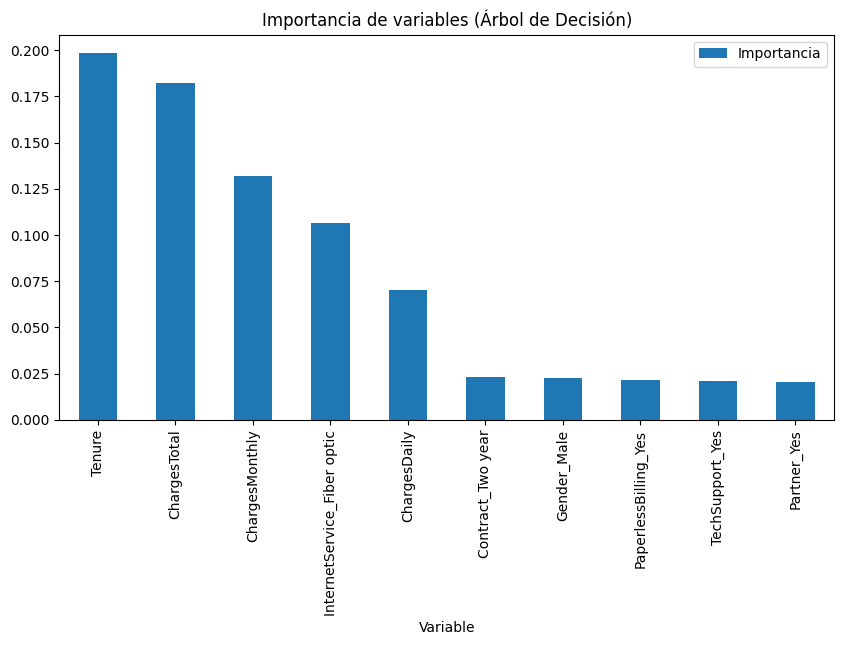

In [66]:
importancias.head(10).plot(
    x="Variable",
    y="Importancia",
    kind="bar",
    figsize=(10,5)
)

plt.title("Importancia de variables (Árbol de Decisión)")
plt.show()

##Informe

A partir del análisis de los modelos y los coeficientes de la Regresión Logística, se identificaron varias variables que influyen significativamente en la cancelación de clientes.

Entre los factores que aumentan la probabilidad de cancelación se encuentran los altos cargos del servicio (ChargesMonthly y ChargesTotal), el uso de Internet de fibra óptica y el método de pago Electronic Check.

Por otro lado, variables como Tenure (tiempo de permanencia) y los contratos de largo plazo (Contract_One year y Contract_Two year) reducen significativamente la probabilidad de cancelación. Esto indica que los clientes con mayor antigüedad o contratos más largos tienden a permanecer más tiempo en la empresa.

Estrategias de retención

Con base en estos resultados, se sugiero tomar las siguientes estrategias para reducir la cancelación de clientes:

Incentivar contratos de largo plazo mediante descuentos o beneficios.

Implementar estrategias de retención para clientes nuevos, quienes presentan mayor riesgo de cancelar.

Revisar la percepción de valor del servicio para clientes con altos cargos mensuales.

Promover servicios adicionales como soporte técnico y seguridad, que pueden mejorar la fidelización.

Conclusión

El análisis muestra que factores como el tiempo de permanencia, el tipo de contrato y los cargos del servicio tienen un impacto importante en la cancelación de clientes. Comprender estos factores permite diseñar estrategias que ayuden a mejorar la retención y reducir el churn.